# Retail Sales Data Analysis

## Objective

The goal of this analysis is to evaluate retail sales data to identify key drivers of profitability and detect loss-making segments.

## Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import charset_normalizer as cn

# make plots look better
sns.set_style("whitegrid")

print("Setup successful")

Setup successful


## Data Loading

In [6]:
with open('superstore.csv', 'rb') as rawdata:
    result = cn.detect(rawdata.read())
print(result)
df = pd.read_csv("superstore.csv", encoding='latin1')

{'encoding': 'windows-1250', 'language': 'English', 'confidence': 1.0}


## Data Understanding

- Total rows and columns
- Data types
- Missing values

In [19]:
df.head()
df.shape
df.info
df.isnull().sum()
df.dtypes
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Profit Margin', 'Year', 'Month'],
      dtype='str')

## Data Cleaning

- Removed unnecessary columns (Postal Code)
- Converted date columns to datetime format

In [ ]:
# removed the column to preserve maximum data(had null values)
# dropna would have removed important data for same row
df.drop(columns=['Postal Code'])

# parsing dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

## Feature Engineering

- Extracted Year and Month from Order Date

In [20]:

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
#print(df[['Order Date', 'Year', 'Month']])


## Exploratory Data Analysis

### Sales by Category

In [9]:
# sales by category
df.groupby('Category')['Sales'].sum()
#df.groupby('Category')['Sales'].sum().plot(kind='bar')
#plt.title('Sales by Category')
#plt.show()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

### Sales by Region

In [10]:
# % sales by region
sales_by_region = df.groupby('Region')['Sales'].sum()/df['Sales'].sum() * 100
sales_by_region
# % contribution of SALES by region
#sales_by_region.plot(kind='bar')
#plt.title('% contribution of SALES by region')
#plt.show()

Region
Central    21.819594
East       29.548188
South      17.052140
West       31.580078
Name: Sales, dtype: float64

### Profit by Category

In [11]:
# profit by Category
df.groupby('Category')['Profit'].sum()
#df.groupby('Category')['Profit'].sum().plot(kind='pie')
#plt.title('Profit by Category')
#plt.show()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

### Profit by Region

In [12]:
# profit by region
df.groupby('Region')['Profit'].sum()
#df.groupby('Region')['Profit'].sum().plot(kind='bar')
#plt.title('Profit')
#plt.show()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64

### Discount vs Profit Analysis

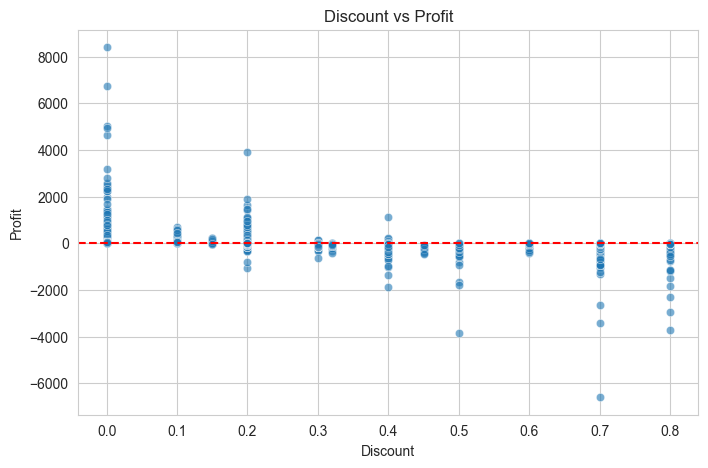

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Discount vs Profit")
plt.show()

### Profit by Sub-Category

In [14]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

### Discount by Sub-Category

In [15]:
df.groupby('Sub-Category')['Discount'].mean().sort_values(ascending=False)

Sub-Category
Binders        0.372292
Machines       0.306087
Tables         0.261285
Bookcases      0.211140
Chairs         0.170178
Appliances     0.166524
Copiers        0.161765
Phones         0.154556
Furnishings    0.138349
Fasteners      0.082028
Envelopes      0.080315
Accessories    0.078452
Supplies       0.076842
Paper          0.074891
Art            0.074874
Storage        0.074704
Labels         0.068681
Name: Discount, dtype: float64

### Profit Margin and Total profit

In [ ]:
# added profit margin column
df['Profit Margin']=df['Profit']/df['Sales']

# total profit
df['Profit'].sum()


np.float64(286397.0217)

## Key Insights

- The business is overall profitable (~286K profit)
- Technology is the highest revenue and profit generating category
- Furniture has significantly lower profit margins
- High discount levels are associated with negative profit
- Sub-categories like Tables and Bookcases are major loss contributors

## Conclusion

The analysis shows that excessive discounting is a key driver of losses in certain sub-categories. Optimizing discount strategies and focusing on high-margin categories can improve overall profitability.

## Recommendations

- Reduce high discounting in Tables and Bookcases
- Focus on expanding high-margin categories like Technology
- Review pricing strategies for low-margin products